# Задание 4. Image Compression using SVD

## Цель

Сжать три изображения с помощью сингулярного разложения (SVD), изменяя ранг низкоранговой аппроксимации.

Для каждого изображения:

1. загрузим изображение;
2. переведём его в grayscale;
3. представим изображение как матрицу интенсивностей пикселей;
4. выполним SVD;
5. восстановим изображение для нескольких значений rank;
6. построим spectrum сингулярных значений;
7. построим explained variance;
8. определим, сколько компонент достаточно для хорошего восстановления.

Идея low-rank approximation:

$$
A = U\\Sigma V^T
$$

$$
A_k = U_k\\Sigma_k V_k^T
$$

где `k` — выбранный ранг. При уменьшении `k` хранится меньше информации, поэтому изображение постепенно теряет детали.


## 1. Импорт библиотек и поиск изображений


In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

RANDOM_STATE = 42

DATA_CANDIDATES = [
    Path("data/Images"),
    Path("../data/Images"),
    Path("../../data/Images"),
]

IMAGES_DIR = next(
    (path for path in DATA_CANDIDATES if path.exists()),
    None,
)

if IMAGES_DIR is None:
    raise FileNotFoundError(
        "Не найдена папка data/Images. Проверь расположение image_1.jpg, image_2.jpg, image_3.jpg."
    )

IMAGE_PATHS = [
    IMAGES_DIR / "image_1.jpg",
    IMAGES_DIR / "image_2.jpg",
    IMAGES_DIR / "image_3.jpg",
]

for path in IMAGE_PATHS:
    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {path.resolve()}")

print("Папка изображений:", IMAGES_DIR.resolve())
for path in IMAGE_PATHS:
    print(path.name, "->", path.resolve())


Папка изображений: C:\Users\User\Desktop\ML6_Unsupervised_learning_ID_1254805-1\src\data\Images
image_1.jpg -> C:\Users\User\Desktop\ML6_Unsupervised_learning_ID_1254805-1\src\data\Images\image_1.jpg
image_2.jpg -> C:\Users\User\Desktop\ML6_Unsupervised_learning_ID_1254805-1\src\data\Images\image_2.jpg
image_3.jpg -> C:\Users\User\Desktop\ML6_Unsupervised_learning_ID_1254805-1\src\data\Images\image_3.jpg


## 2. Загрузка и перевод в grayscale

По условию SVD-компрессия выполняется для grayscale-изображений. Поэтому каждое изображение преобразуем в режим `L`, после чего получаем матрицу значений от 0 до 255.


In [2]:
images = {}

for path in IMAGE_PATHS:
    image = Image.open(path).convert("L")
    matrix = np.asarray(image, dtype=np.float64)
    images[path.stem] = matrix

    print(f"{path.name}: shape={matrix.shape}, min={matrix.min():.0f}, max={matrix.max():.0f}")


image_1.jpg: shape=(3456, 5184), min=30, max=255
image_2.jpg: shape=(2733, 4096), min=1, max=255
image_3.jpg: shape=(3009, 4513), min=0, max=252


## 3. Исходные изображения


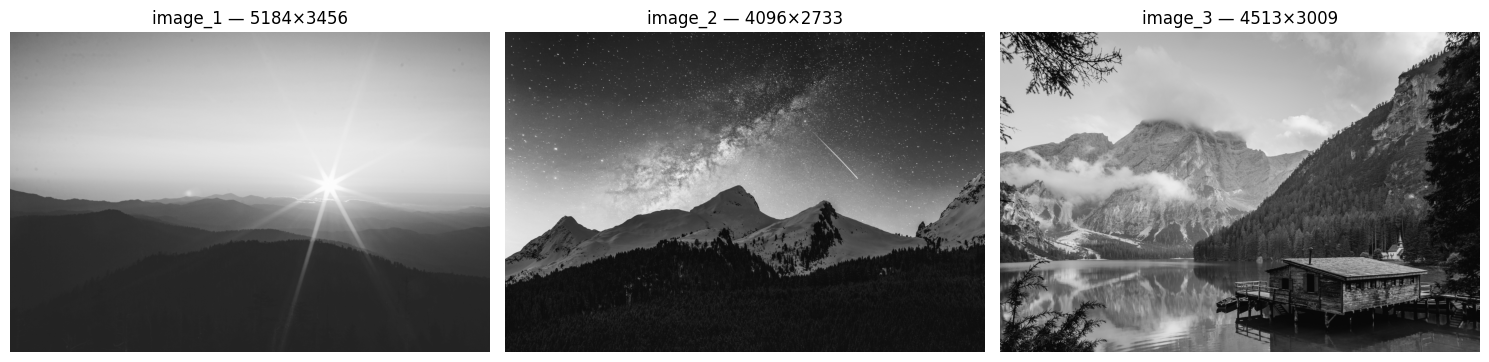

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, matrix) in zip(axes, images.items()):
    ax.imshow(matrix, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{name} — {matrix.shape[1]}×{matrix.shape[0]}")
    ax.axis("off")

plt.tight_layout()
plt.show()


# 4. SVD для изображения

Для матрицы изображения `A` вычисляем:

$$
A = U\\Sigma V^T
$$

После этого для любого ранга `k` можно построить:

$$
A_k = U[:, :k]\\Sigma[:k]V^T[:k, :]
$$

Чем меньше `k`, тем меньше информации используется для реконструкции.


In [4]:
svd_data = {}

for name, matrix in images.items():
    start = time.perf_counter()
    U, singular_values, VT = np.linalg.svd(matrix, full_matrices=False)
    elapsed = time.perf_counter() - start

    svd_data[name] = {
        "matrix": matrix,
        "U": U,
        "singular_values": singular_values,
        "VT": VT,
        "svd_time": elapsed,
    }

    print(
        f"{name}: singular values = {len(singular_values)}, "
        f"SVD time = {elapsed:.4f} sec"
    )


image_1: singular values = 3456, SVD time = 28.4181 sec
image_2: singular values = 2733, SVD time = 9.4775 sec
image_3: singular values = 3009, SVD time = 38.7847 sec


## 5. Выбираем 10 значений rank

Количество компонент не может превышать `min(height, width)`.
Поэтому значения rank формируются автоматически и включают как очень низкий, так и более высокий уровень детализации.


In [5]:
def make_ranks(max_rank, n=10):
    if max_rank <= n:
        return list(range(1, max_rank + 1))

    raw = np.geomspace(1, max_rank, num=n)
    ranks = sorted(set(np.round(raw).astype(int).tolist()))
    ranks = sorted(set([1, *ranks, max_rank]))

    # Оставляем не более n значений, равномерно выбирая индексы.
    if len(ranks) > n:
        idx = np.linspace(0, len(ranks) - 1, n).round().astype(int)
        ranks = [ranks[i] for i in idx]

    return sorted(set(ranks))


for name, data in svd_data.items():
    max_rank = len(data["singular_values"])
    data["ranks"] = make_ranks(max_rank, n=10)
    print(name, "ranks:", data["ranks"])


image_1 ranks: [1, 2, 6, 15, 37, 92, 229, 565, 1398, 3456]
image_2 ranks: [1, 2, 6, 14, 34, 81, 195, 471, 1134, 2733]
image_3 ranks: [1, 2, 6, 14, 35, 86, 208, 508, 1236, 3009]


## 6. Функция восстановления изображения для заданного rank


In [6]:
def reconstruct_from_svd(U, singular_values, VT, rank):
    rank = int(rank)
    U_k = U[:, :rank]
    S_k = singular_values[:rank]
    VT_k = VT[:rank, :]

    reconstructed = (U_k * S_k) @ VT_k
    return np.clip(reconstructed, 0, 255)


# 7. Визуализация реконструкций

Для каждого исходного изображения показываем 10 вариантов с разными rank. Это позволяет непосредственно увидеть, как изображение становится менее детальным при уменьшении количества компонент.


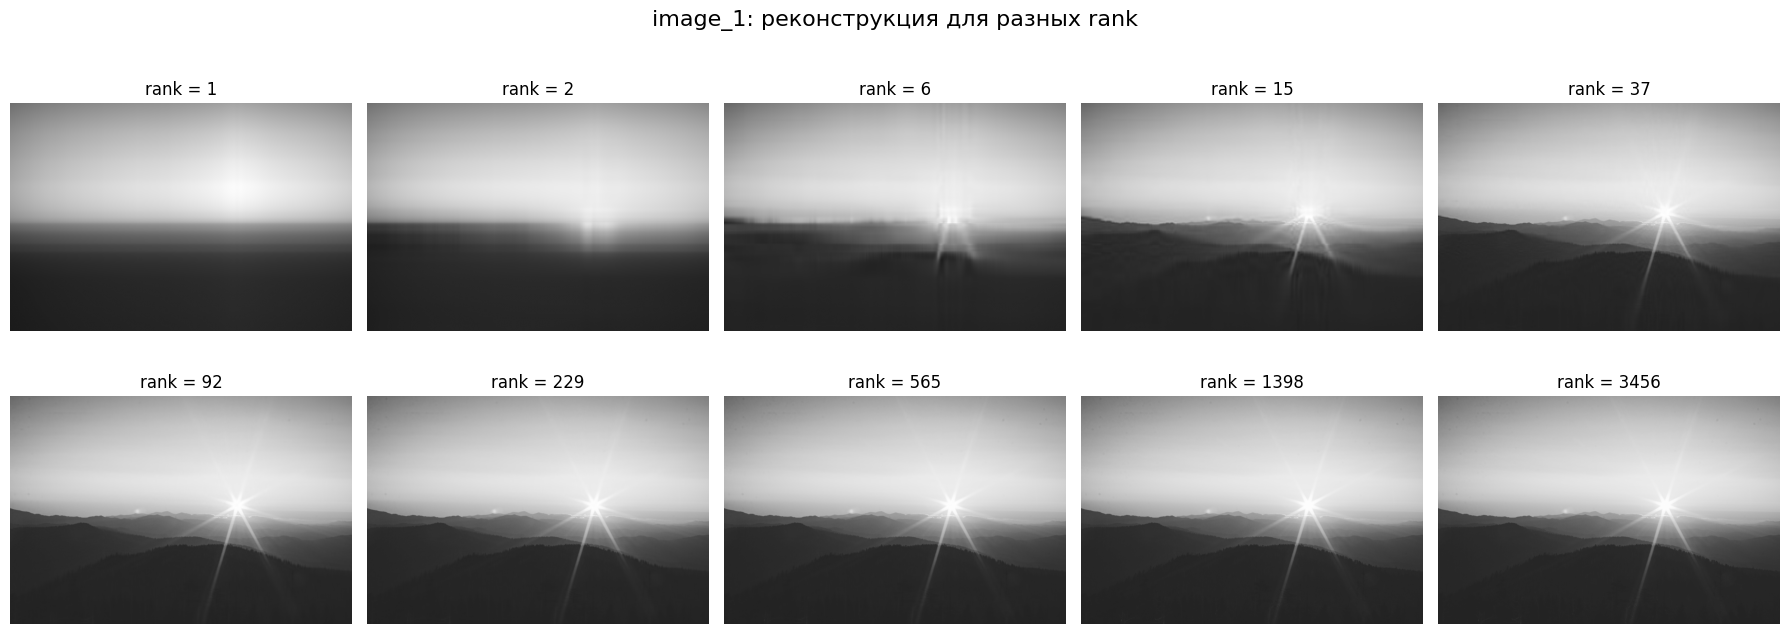

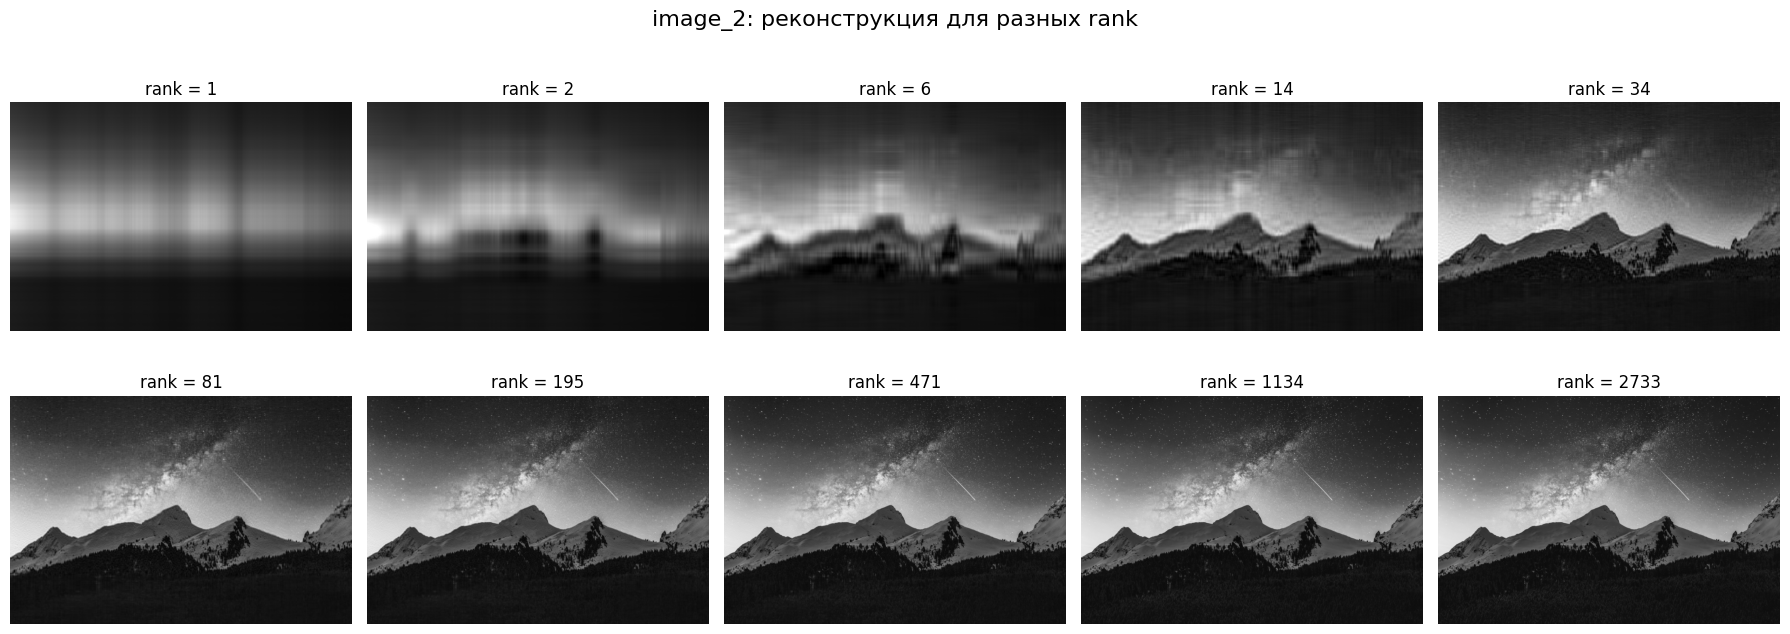

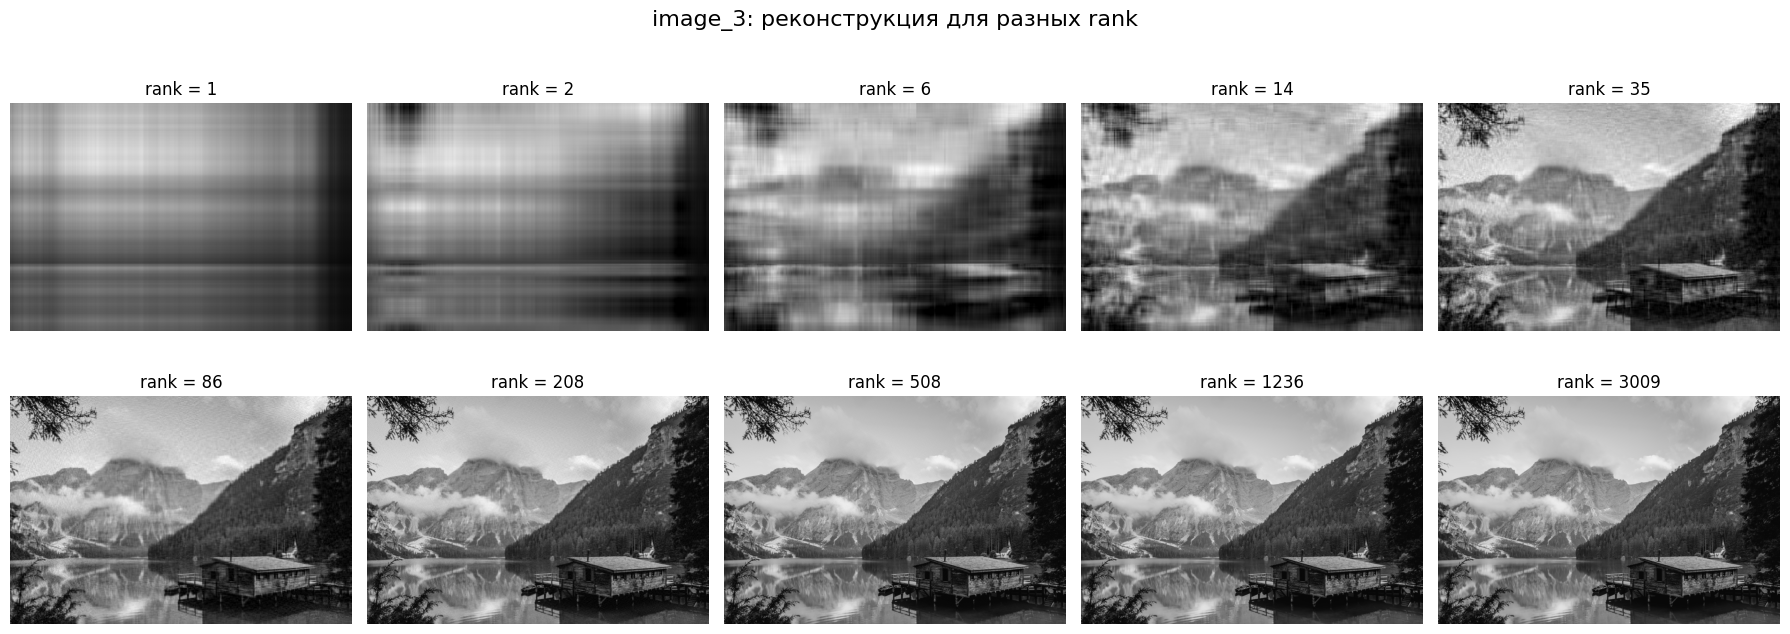

In [7]:
for name, data in svd_data.items():
    ranks = data["ranks"]
    n_cols = 5
    n_rows = int(np.ceil(len(ranks) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 3.5 * n_rows),
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, rank in zip(axes, ranks):
        reconstructed = reconstruct_from_svd(
            data["U"],
            data["singular_values"],
            data["VT"],
            rank,
        )
        ax.imshow(reconstructed, cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"rank = {rank}")
        ax.axis("off")

    for ax in axes[len(ranks):]:
        ax.axis("off")

    fig.suptitle(f"{name}: реконструкция для разных rank", fontsize=16)
    plt.tight_layout()
    plt.show()


# 8. Spectrum сингулярных значений

Сингулярные значения показывают, сколько информации связано с соответствующими сингулярными компонентами.

Если первые значения значительно больше последующих, то большую часть структуры изображения можно восстановить небольшим числом компонент.


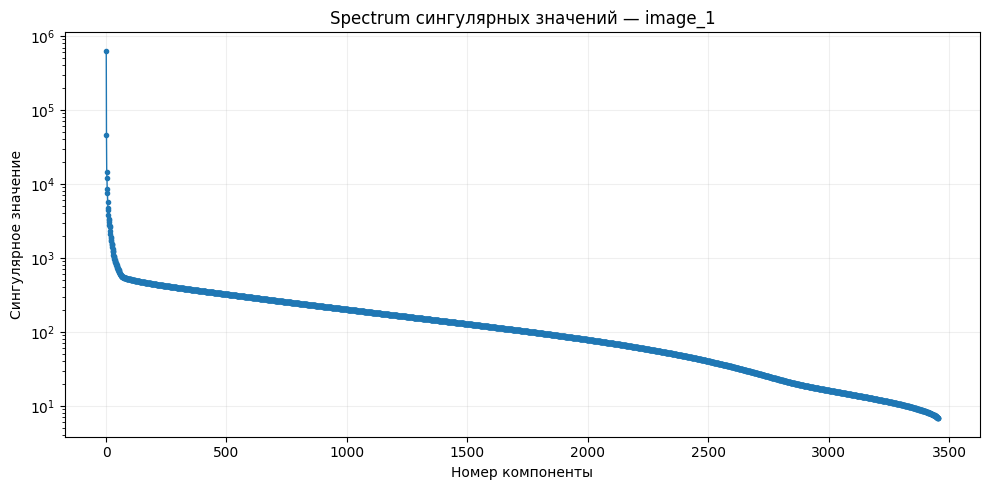

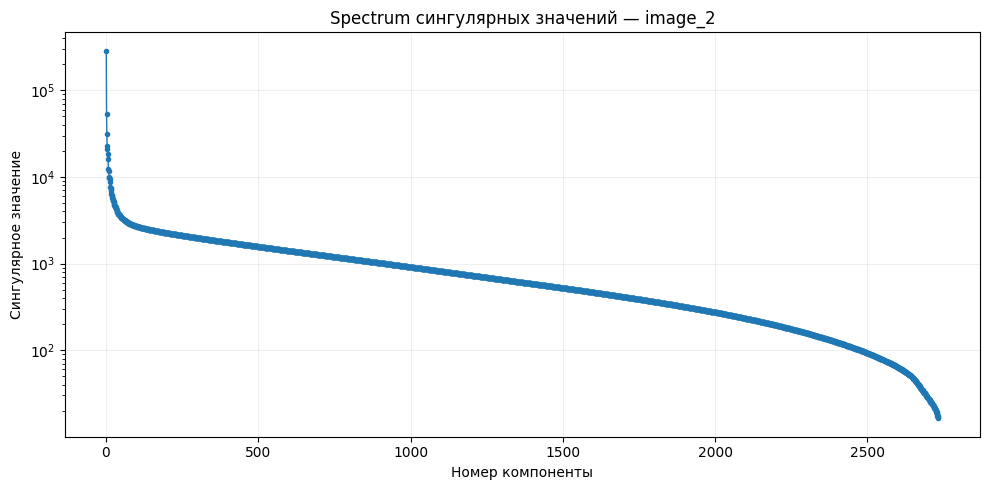

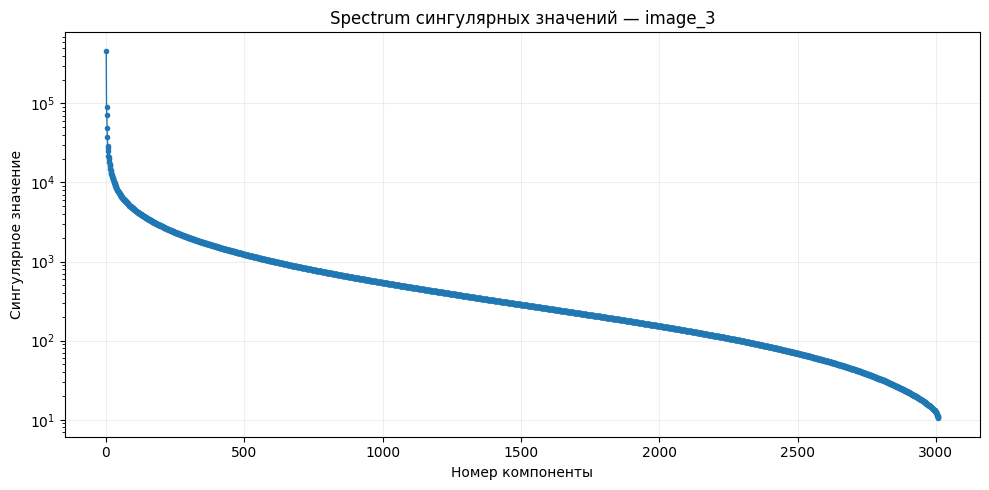

In [8]:
for name, data in svd_data.items():
    singular_values = data["singular_values"]
    ranks = data["ranks"]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(
        np.arange(1, len(singular_values) + 1),
        singular_values,
        marker="o",
        markersize=3,
        linewidth=1,
    )
    ax.set_title(f"Spectrum сингулярных значений — {name}")
    ax.set_xlabel("Номер компоненты")
    ax.set_ylabel("Сингулярное значение")
    ax.set_yscale("log")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


# 9. Explained variance

Для SVD доля объяснённой энергии первых `k` компонент рассчитывается как:

$$
EV(k) = 
\frac{\\sum_{i=1}^{k} \\sigma_i^2}
{\\sum_{i=1}^{r} \\sigma_i^2}
$$

где `r = min(height, width)`.

Чем ближе `EV(k)` к 1, тем больше общей энергии изображения объясняется первыми `k` компонентами.


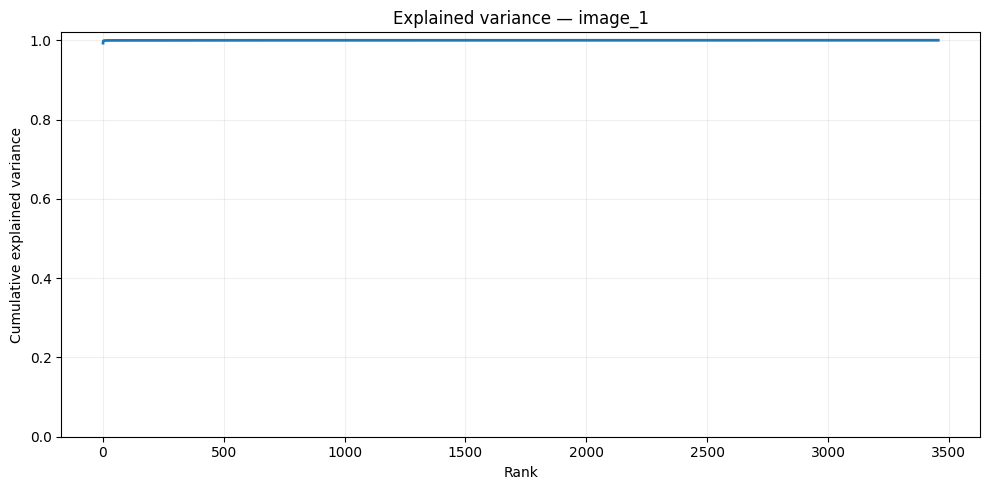

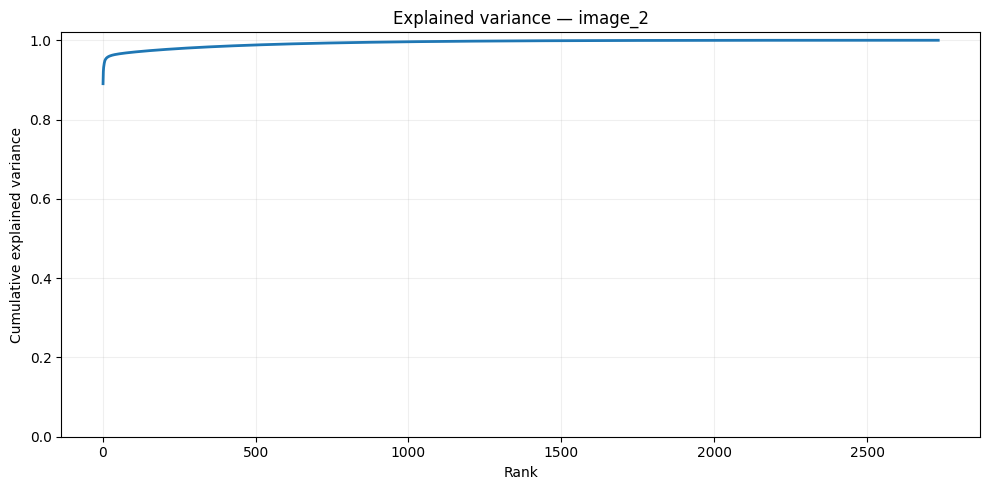

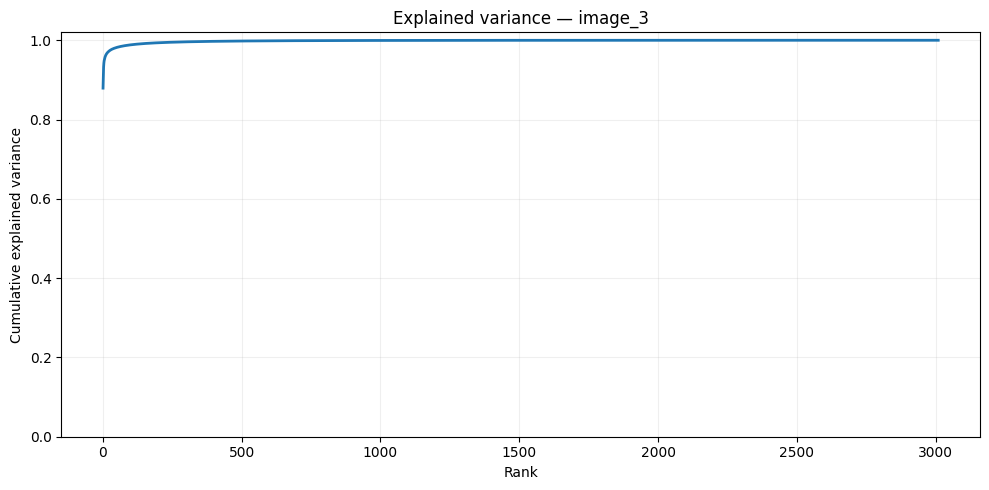

In [9]:
compression_results = []

for name, data in svd_data.items():
    sigma = data["singular_values"]
    energy = sigma ** 2
    explained = np.cumsum(energy) / np.sum(energy)
    data["explained_variance"] = explained

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(
        np.arange(1, len(explained) + 1),
        explained,
        linewidth=2,
    )
    ax.set_title(f"Explained variance — {name}")
    ax.set_xlabel("Rank")
    ax.set_ylabel("Cumulative explained variance")
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


## 10. Находим rank для 90%, 95% и 99% объяснённой дисперсии


In [10]:
thresholds = [0.90, 0.95, 0.99]

variance_rows = []

for name, data in svd_data.items():
    explained = data["explained_variance"]

    row = {"Image": name}
    for threshold in thresholds:
        rank = int(np.searchsorted(explained, threshold) + 1)
        row[f"Rank for {int(threshold * 100)}%"] = rank
    variance_rows.append(row)

variance_df = pd.DataFrame(variance_rows)
display(variance_df)


,Image,Rank for 90%,Rank for 95%,Rank for 99%
0,image_1,1,1,1
1,image_2,2,8,576
2,image_3,2,6,121


# 11. Ошибка реконструкции

Для более объективного сравнения вычисляем относительную ошибку Фробениуса:

$$
Error(k) = 
\frac{||A-A_k||_F}{||A||_F}
$$

Меньшее значение означает более точное восстановление изображения.


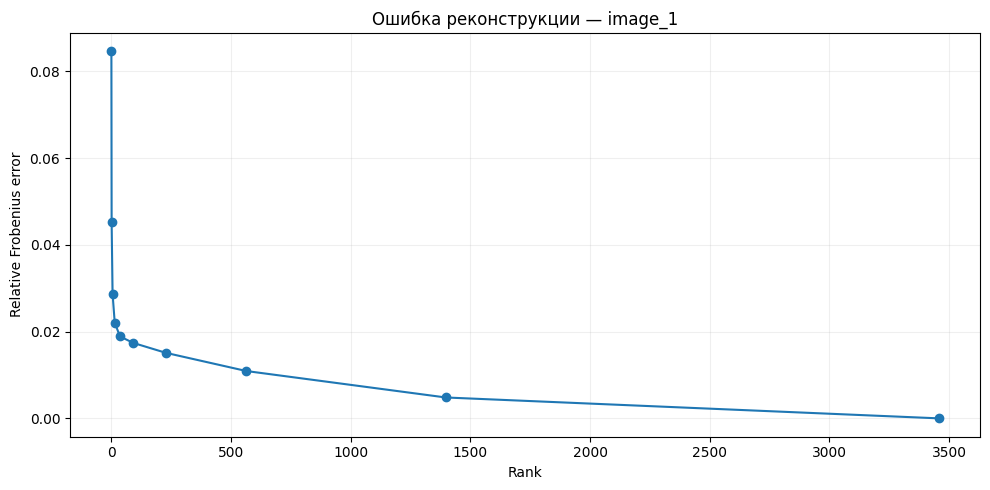

,Rank,Explained variance,Relative Frobenius error
0,1,0.992830,0.084677
1,2,0.997955,0.045221
2,6,0.999180,0.028634
3,15,0.999515,0.022017
4,37,0.999644,0.018880
5,92,0.999698,0.017389
6,229,0.999772,0.015092
7,565,0.999881,0.010903
8,1398,0.999977,0.004809
9,3456,1.000000,0.000000


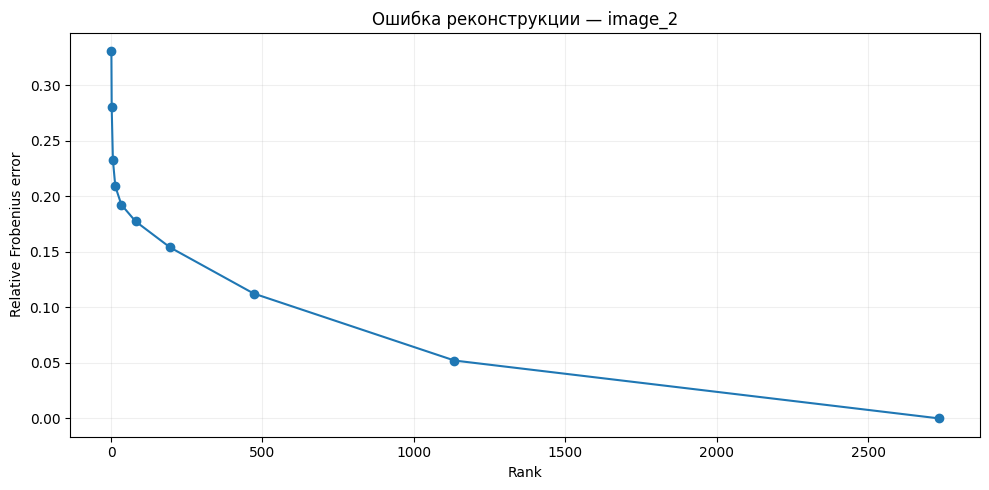

,Rank,Explained variance,Relative Frobenius error
0,1,0.890420,0.331029
1,2,0.921189,0.280198
2,6,0.945816,0.232649
3,14,0.956339,0.208941
4,34,0.962954,0.192465
5,81,0.968515,0.177432
6,195,0.976294,0.153952
7,471,0.987344,0.112455
8,1134,0.997285,0.052093
9,2733,1.000000,0.000000


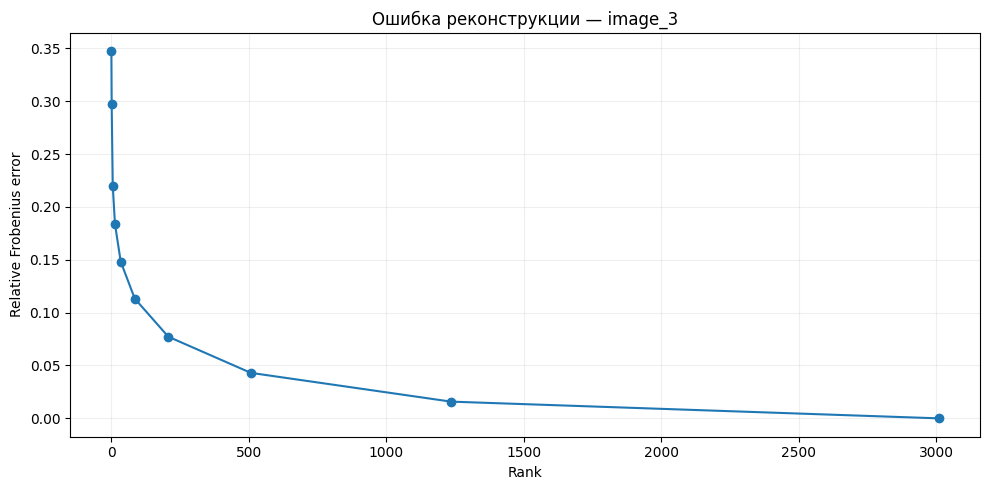

,Rank,Explained variance,Relative Frobenius error
0,1,0.879219,0.347535
1,2,0.911627,0.297205
2,6,0.951633,0.219744
3,14,0.966188,0.183817
4,35,0.978019,0.148124
5,86,0.987109,0.113248
6,208,0.993996,0.077224
7,508,0.998144,0.043029
8,1236,0.999750,0.015819
9,3009,1.000000,0.000000


In [11]:
for name, data in svd_data.items():
    original = data["matrix"]
    original_norm = np.linalg.norm(original, ord="fro")

    rows = []
    for rank in data["ranks"]:
        reconstructed = reconstruct_from_svd(
            data["U"],
            data["singular_values"],
            data["VT"],
            rank,
        )
        error = np.linalg.norm(original - reconstructed, ord="fro") / original_norm
        explained = data["explained_variance"][rank - 1]

        rows.append({
            "Rank": rank,
            "Explained variance": explained,
            "Relative Frobenius error": error,
        })

    error_df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(
        error_df["Rank"],
        error_df["Relative Frobenius error"],
        marker="o",
    )
    ax.set_title(f"Ошибка реконструкции — {name}")
    ax.set_xlabel("Rank")
    ax.set_ylabel("Relative Frobenius error")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    display(error_df.round(6))


# 12. Сравнение объёма хранения

Для исходной матрицы `m × n` количество значений равно:

`m × n`.

Для SVD rank `k` можно хранить примерно:

`m × k + k + k × n`

значений.

Таким образом, низкий rank может существенно уменьшить объём представления.


In [12]:
storage_rows = []

for name, data in svd_data.items():
    m, n = data["matrix"].shape
    original_values = m * n

    for rank in data["ranks"]:
        svd_values = m * rank + rank + rank * n
        compression_ratio = original_values / svd_values
        explained = data["explained_variance"][rank - 1]

        storage_rows.append({
            "Image": name,
            "Rank": rank,
            "Original values": original_values,
            "SVD values": svd_values,
            "Compression ratio": compression_ratio,
            "Explained variance": explained,
        })

storage_df = pd.DataFrame(storage_rows)
display(
    storage_df.round({
        "Compression ratio": 2,
        "Explained variance": 4,
    })
)


,Image,Rank,Original values,SVD values,Compression ratio,Explained variance
0,image_1,1,17915904,8641,2073.36,0.9928
1,image_1,2,17915904,17282,1036.68,0.9980
2,image_1,6,17915904,51846,345.56,0.9992
3,image_1,15,17915904,129615,138.22,0.9995
4,image_1,37,17915904,319717,56.04,0.9996
5,image_1,92,17915904,794972,22.54,0.9997
6,image_1,229,17915904,1978789,9.05,0.9998
7,image_1,565,17915904,4882165,3.67,0.9999
8,image_1,1398,17915904,12080118,1.48,1.0000
9,image_1,3456,17915904,29863296,0.60,1.0000


# 13. Итоговые выводы

При анализе результатов нужно обратить внимание на следующие закономерности:

1. При уменьшении `rank` размер SVD-представления уменьшается.
2. Вместе с этим уменьшается количество сохранённой информации и растёт ошибка реконструкции.
3. При увеличении `rank` изображение становится визуально ближе к оригиналу.
4. По графику explained variance можно выбрать разумный компромисс между качеством и количеством компонентов.
5. Наличие резкого падения spectrum сингулярных значений означает, что значительная часть структуры изображения может быть представлена небольшим числом компонент.

По чек-листу важно, чтобы пример наглядно демонстрировал ухудшение чёткости изображения при уменьшении числа компонент.


# Контрольный список Task 4

- [x] Три изображения загружены
- [x] Изображения переведены в grayscale
- [x] Каждое изображение представлено матрицей пикселей
- [x] Выполнен SVD
- [x] Использованы разные значения rank
- [x] Построены восстановленные изображения
- [x] Построен spectrum сингулярных значений
- [x] Рассчитана explained variance
- [x] Найдены rank для 90%, 95% и 99% explained variance
- [x] Рассчитана ошибка реконструкции
- [x] Оценён выигрыш по объёму хранения
- [x] Сформированы выводы о компромиссе качество / rank
